# Exploratory Data Analysis (EDA): Dataset MovieLens 25M (ml-25m)

analisis data eksploratif (EDA) untuk dataset MovieLens 25M:
1. `movies.csv`: Data film (judul, genre, tahun rilis).
2. `ratings.csv`: Data rating interaksi user terhadap film (optimasi memori untuk ~25 juta baris).
3. `tags.csv`: Tag yang diberikan oleh user pada film.
4. `links.csv`: ID referensi eksternal (IMDb dan TMDb).
5. `genome-tags.csv` & `genome-scores.csv`: Data relevansi tag (Tag Genome).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Analisis Data Film (`movies.csv`)
Kita akan memuat data film, mengekstrak tahun rilis dari judul, dan menganalisis tren perilisan serta distribusi genre.

In [2]:
movies_path = 'ml-25m/movies.csv'
movies_df = pd.read_csv(movies_path)
print(f"Shape of movies_df: {movies_df.shape}")
print("\nFirst 5 rows:")
print(movies_df.head())
print("\nMissing values:")
print(movies_df.isnull().sum())

Shape of movies_df: (62423, 3)

First 5 rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Missing values:
movieId    0
title      0
genres     0
dtype: int64


### Ekstraksi dan Analisis Tahun Rilis
Tahun rilis berada di dalam tanda kurung di akhir judul (misalnya: `Toy Story (1995)`). Kita gunakan regex untuk mengekstraknya.

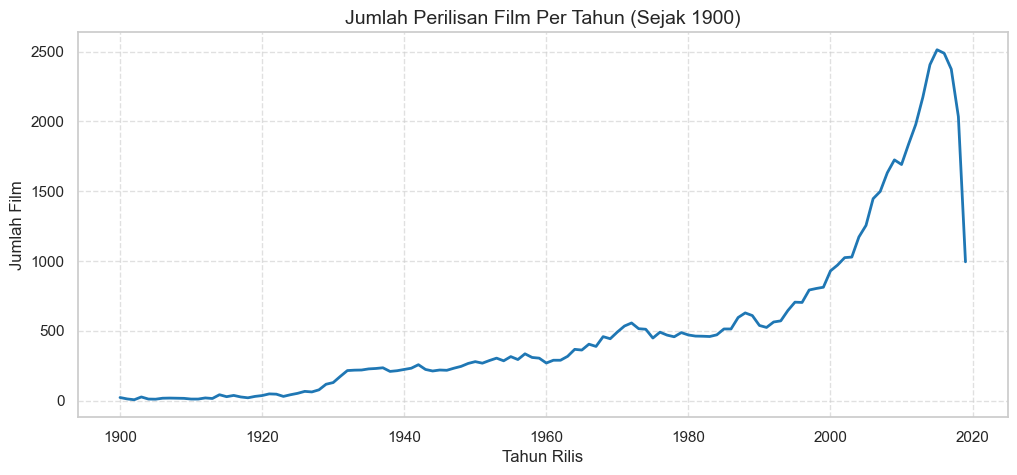

Jumlah film tanpa tahun rilis yang valid: 412


In [3]:
def extract_year(title):
    match = re.search(r'\((\d{4})\)\s*$', title)
    return int(match.group(1)) if match else np.nan

movies_df['year'] = movies_df['title'].apply(extract_year)

# Plot tren perilisan film per tahun (sejak tahun 1900)
years_count = movies_df[movies_df['year'] >= 1900]['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(years_count.index, years_count.values, color='#1f77b4', linewidth=2)
plt.title('Jumlah Perilisan Film Per Tahun (Sejak 1900)', fontsize=14)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Jumlah film tanpa tahun rilis yang valid: {movies_df['year'].isnull().sum()}")

### Analisis Distribusi Genre Film
Setiap film dapat memiliki beberapa genre yang dipisahkan oleh karakter `|`. Kita akan memecah genre tersebut untuk menghitung total frekuensi masing-masing genre.

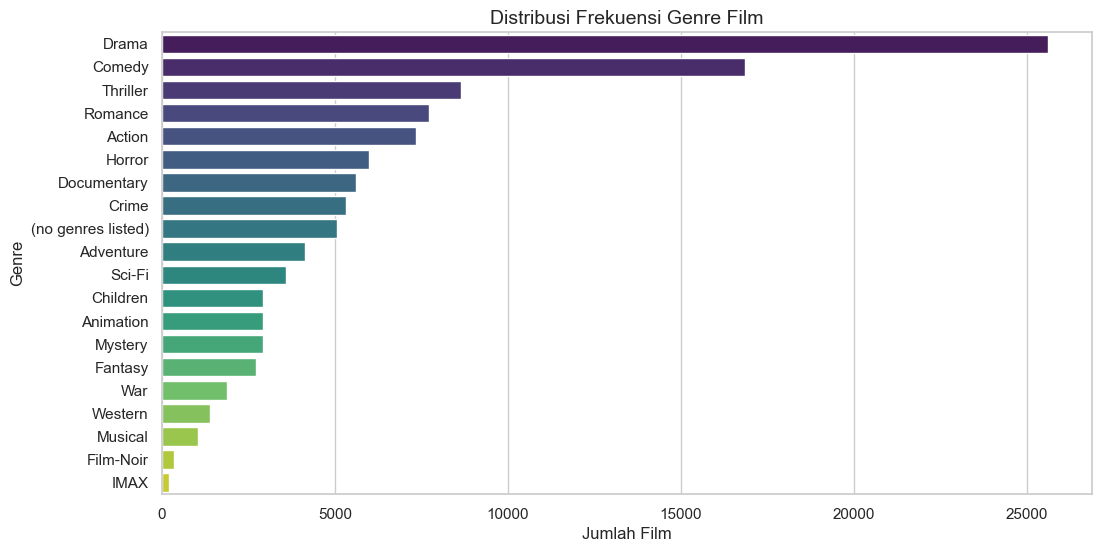

Frekuensi Genre:
genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64


In [4]:
# Pecah string genre menjadi list, lalu explode
genres_exploded = movies_df['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Distribusi Frekuensi Genre Film', fontsize=14)
plt.xlabel('Jumlah Film', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

print("Frekuensi Genre:")
print(genre_counts)

## 2. Analisis Data Rating (`ratings.csv`)
ukuran file `ratings.csv` cukup besar (~25 juta baris, ~678MB)

In [5]:
ratings_path = 'ml-25m/ratings.csv'
# Menggunakan dtype int32 dan float32 untuk efisiensi memori, timestamp dilewati dulu
ratings_df = pd.read_csv(ratings_path, dtype={
    'userId': np.int32,
    'movieId': np.int32,
    'rating': np.float32
}, usecols=['userId', 'movieId', 'rating'])

print(f"Shape of ratings_df: {ratings_df.shape}")
print(f"Memory Usage: {ratings_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
print("\nFirst 5 rows:")
print(ratings_df.head())

Shape of ratings_df: (25000095, 3)
Memory Usage: 286.10 MB

First 5 rows:
   userId  movieId  rating
0       1      296     5.0
1       1      306     3.5
2       1      307     5.0
3       1      665     5.0
4       1      899     3.5


### Distribusi Nilai Rating
Mari kita lihat sebaran nilai rating dari 0.5 hingga 5.0.

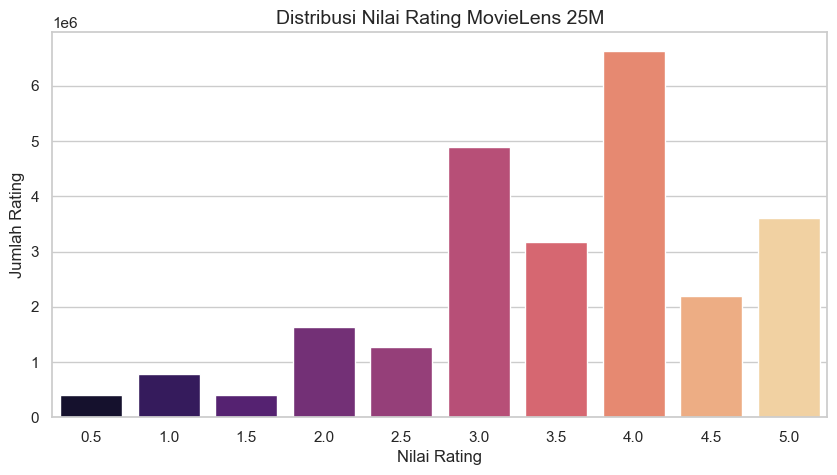

Frekuensi Nilai Rating:
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64


In [6]:
rating_counts = ratings_df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='magma')
plt.title('Distribusi Nilai Rating MovieLens 25M', fontsize=14)
plt.xlabel('Nilai Rating', fontsize=12)
plt.ylabel('Jumlah Rating', fontsize=12)
plt.show()

print("Frekuensi Nilai Rating:")
print(rating_counts)

### Aktivitas Rating per User
Berapa banyak rating yang biasanya diberikan oleh seorang user?

Statistik Aktivitas Rating per User:
count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
Name: count, dtype: float64


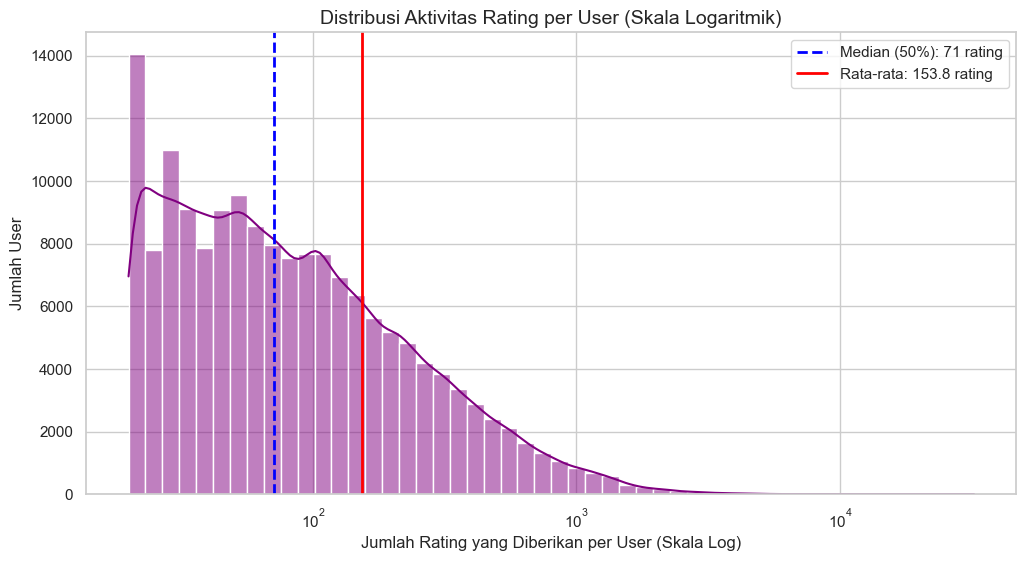

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

user_activity = ratings_df['userId'].value_counts()
print("Statistik Aktivitas Rating per User:")
print(user_activity.describe())

# Mengambil nilai rata-rata dan median dari data
mean_val = user_activity.mean()
median_val = user_activity.median()

# Plot distribusi aktivitas rating per user (skala logaritmik)
plt.figure(figsize=(12, 6))
sns.histplot(user_activity.values, bins=50, log_scale=True, color='purple', kde=True)

# Garis vertikal untuk Median (Kuartil 2)
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, 
            label=f'Median (50%): {median_val:.0f} rating')

# Garis vertikal untuk Rata-rata (Mean)
plt.axvline(mean_val, color='red', linestyle='-', linewidth=2, 
            label=f'Rata-rata: {mean_val:.1f} rating')

plt.title('Distribusi Aktivitas Rating per User (Skala Logaritmik)', fontsize=14)
plt.xlabel('Jumlah Rating yang Diberikan per User (Skala Log)', fontsize=12)
plt.ylabel('Jumlah User', fontsize=12)

# Garis pembantu
plt.legend(fontsize=11)
plt.show()


### Uyy Apa masuk akal addda User memberikan 32202 rating? 

### Popularitas Film (Jumlah Rating per Film)
Berapa banyak rating yang diperoleh oleh masing-masing film?

Statistik Popularitas Film (Jumlah Rating):
count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
Name: count, dtype: float64


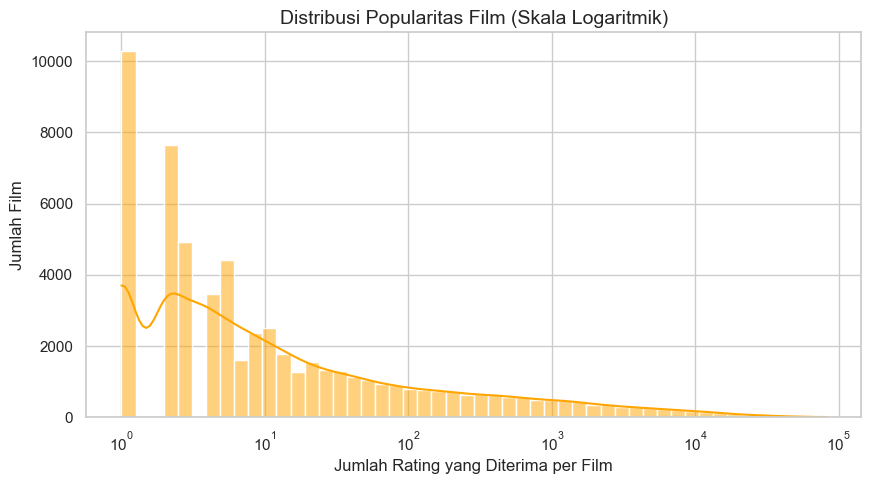

In [8]:
movie_popularity = ratings_df['movieId'].value_counts()
print("Statistik Popularitas Film (Jumlah Rating):")
print(movie_popularity.describe())

# Plot distribusi jumlah rating per film (long tail)
plt.figure(figsize=(10, 5))
sns.histplot(movie_popularity.values, bins=50, log_scale=True, color='orange', kde=True)
plt.title('Distribusi Popularitas Film (Skala Logaritmik)', fontsize=14)
plt.xlabel('Jumlah Rating yang Diterima per Film', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)
plt.show()

### Distribusi Rata-rata Rating per Film
Distribusi rata-rata rating untuk masing-masing film.

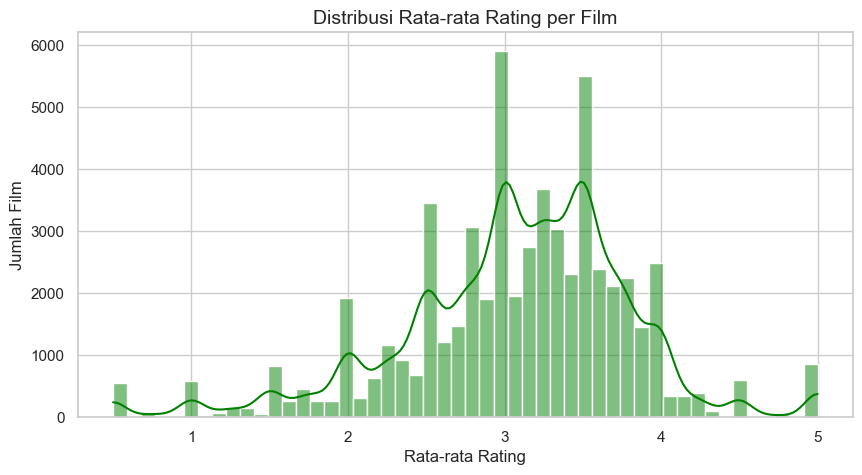

Statistik Rata-rata Rating per Film:
count    59047.000000
mean         3.071374
std          0.739840
min          0.500000
25%          2.687500
50%          3.150000
75%          3.500000
max          5.000000
Name: rating, dtype: float64


In [9]:
# Hitung rata-rata rating per film
movie_means = ratings_df.groupby('movieId')['rating'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(movie_means.values, bins=50, color='green', kde=True)
plt.title('Distribusi Rata-rata Rating per Film', fontsize=14)
plt.xlabel('Rata-rata Rating', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)
plt.show()

print("Statistik Rata-rata Rating per Film:")
print(movie_means.describe())

## 3. Analisis Data Tagging (`tags.csv`)
Data tagging berisi tag teks bebas yang diberikan oleh user pada film tertentu.

In [10]:
tags_path = 'ml-25m/tags.csv'
tags_df = pd.read_csv(tags_path, dtype={
    'userId': np.int32,
    'movieId': np.int32,
    'tag': str
})
print(f"Shape of tags_df: {tags_df.shape}")
print("\nFirst 5 rows:")
print(tags_df.head())
print("\nMissing values in tag column:")
print(tags_df['tag'].isnull().sum())

# Hapus baris dengan tag null
tags_df = tags_df.dropna(subset=['tag'])

Shape of tags_df: (1093360, 4)

First 5 rows:
   userId  movieId               tag   timestamp
0       3      260           classic  1439472355
1       3      260            sci-fi  1439472256
2       4     1732       dark comedy  1573943598
3       4     1732    great dialogue  1573943604
4       4     7569  so bad it's good  1573943455

Missing values in tag column:
16


### Top 20 Tag Terpopuler
Tag apa saja yang paling sering disematkan oleh user? Kita lakukan standarisasi lowercase terlebih dahulu.

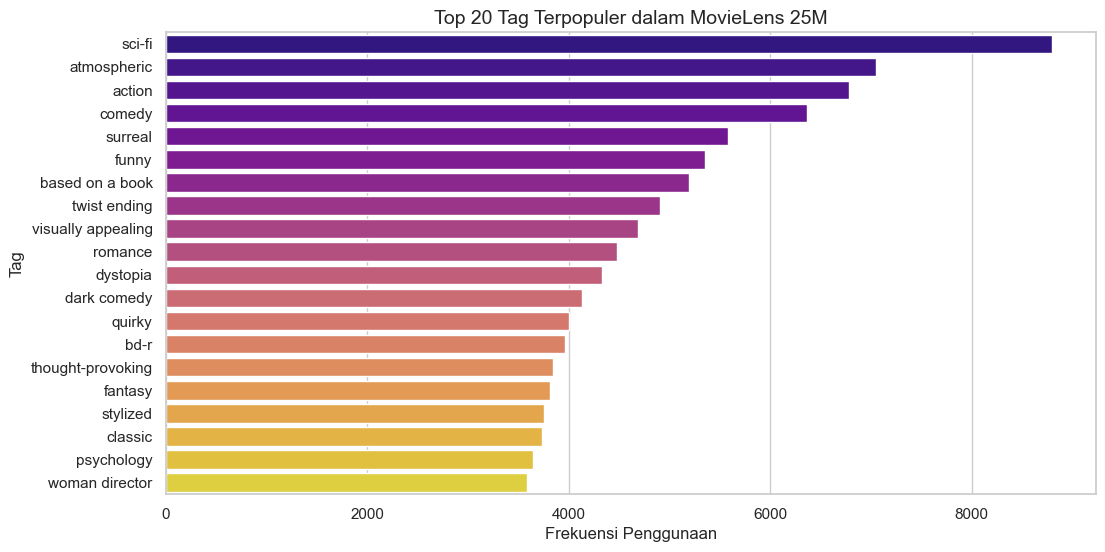

Top 20 Tag Terpopuler:
tag_clean
sci-fi                8795
atmospheric           7053
action                6783
comedy                6368
surreal               5584
funny                 5354
based on a book       5194
twist ending          4904
visually appealing    4691
romance               4482
dystopia              4329
dark comedy           4133
quirky                3999
bd-r                  3966
thought-provoking     3847
fantasy               3816
stylized              3758
classic               3733
psychology            3646
woman director        3590
Name: count, dtype: int64


In [11]:
tags_df['tag_clean'] = tags_df['tag'].str.strip().str.lower()
top_tags = tags_df['tag_clean'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='plasma')
plt.title('Top 20 Tag Terpopuler dalam MovieLens 25M', fontsize=14)
plt.xlabel('Frekuensi Penggunaan', fontsize=12)
plt.ylabel('Tag', fontsize=12)
plt.show()

print("Top 20 Tag Terpopuler:")
print(top_tags)

## 4. Analisis Data Link Referensi (`links.csv`)
File `links.csv` berisi pemetaan `movieId` ke ID eksternal seperti IMDb dan TMDb. Kita cek kelengkapan datanya.

In [12]:
links_path = 'ml-25m/links.csv'
links_df = pd.read_csv(links_path)
print(f"Shape of links_df: {links_df.shape}")
print("\nMissing values in links:")
print(links_df.isnull().sum())
print("\nFirst 5 rows:")
print(links_df.head())

Shape of links_df: (62423, 3)

Missing values in links:
movieId      0
imdbId       0
tmdbId     107
dtype: int64

First 5 rows:
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


## 5. Analisis Tag Genome (`genome-tags.csv` & `genome-scores.csv`)
Tag genome memuat relevansi matematis antara film dengan 1128 tag yang ada di sistem MovieLens. Nilai relevance berkisar dari 0.0 sampai 1.0.

In [13]:
genome_tags_path = 'ml-25m/genome-tags.csv'
genome_scores_path = 'ml-25m/genome-scores.csv'

genome_tags = pd.read_csv(genome_tags_path)
# Optimasi memori untuk genome scores
genome_scores = pd.read_csv(genome_scores_path, dtype={
    'movieId': np.int32,
    'tagId': np.int16,
    'relevance': np.float32
})

print(f"Shape of genome_tags: {genome_tags.shape}")
print(f"Shape of genome_scores: {genome_scores.shape}")
print(f"\nFirst 5 rows of genome scores:")
print(genome_scores.head())

Shape of genome_tags: (1128, 2)
Shape of genome_scores: (15584448, 3)

First 5 rows of genome scores:
   movieId  tagId  relevance
0        1      1    0.02875
1        1      2    0.02375
2        1      3    0.06250
3        1      4    0.07575
4        1      5    0.14075


### Distribusi Nilai Relevance
Mari kita plot sebaran nilai relevansi tag genome ini.

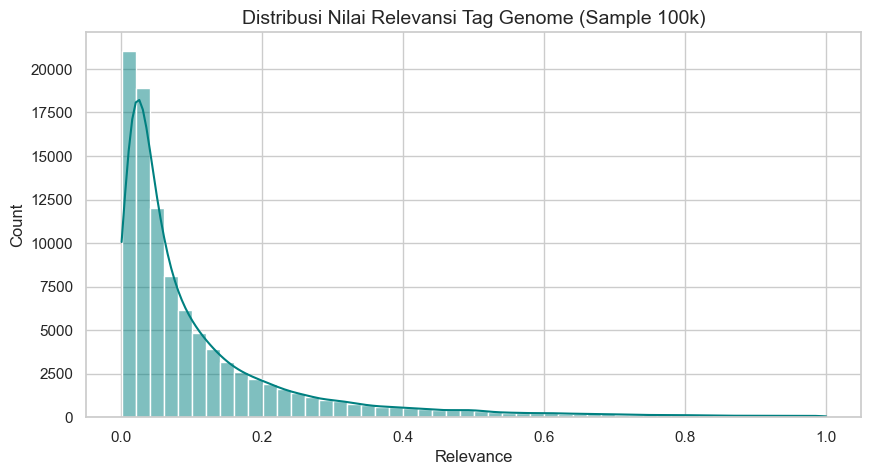

Statistik Deskriptif Relevance:
count    1.558445e+07
mean     1.163677e-01
std      1.544722e-01
min      2.500000e-04
25%      2.400000e-02
50%      5.650000e-02
75%      1.407500e-01
max      1.000000e+00
Name: relevance, dtype: float64


In [21]:
plt.figure(figsize=(10, 5))
# Kita sample sebagian kecil data untuk mempercepat plotting visualisasi histogram
sample_scores = genome_scores['relevance'].sample(n=100000, random_state=42)
sns.histplot(sample_scores, bins=50, kde=True, color='teal')
plt.title('Distribusi Nilai Relevansi Tag Genome (Sample 100k)', fontsize=14)
plt.xlabel('Relevance', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("Statistik Deskriptif Relevance:")
print(genome_scores['relevance'].describe())

### Studi Kasus: Tag dengan Relevansi Tertinggi untuk Film "Toy Story" (movieId = 1)
Mari kita lihat tag genome apa saja yang memiliki nilai relevansi paling kuat (> 0.8) untuk film *Toy Story*.

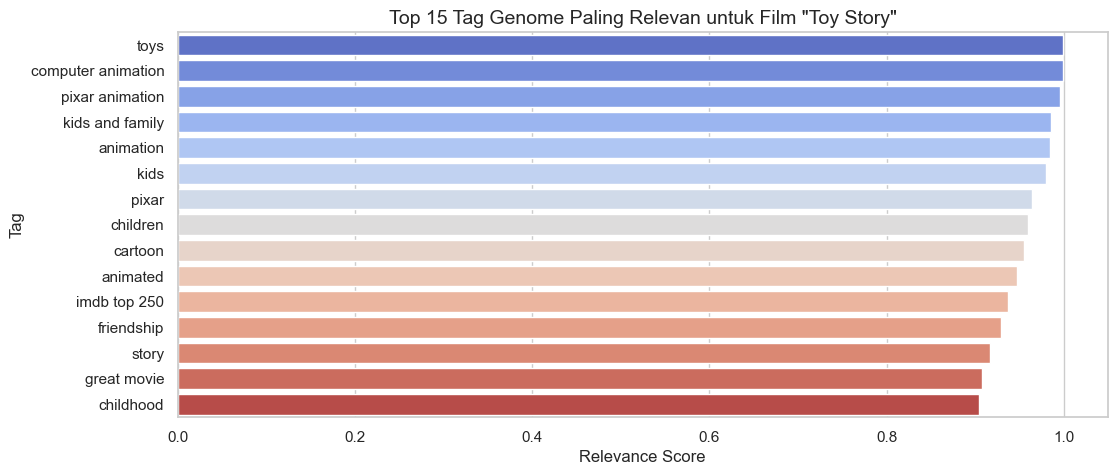

Top 15 Tag Relevan untuk Toy Story:
                     tag  relevance
1035                toys    0.99925
243   computer animation    0.99875
785      pixar animation    0.99575
588      kids and family    0.98575
63             animation    0.98425
587                 kids    0.98000
784                pixar    0.96450
203             children    0.95975
185              cartoon    0.95475
62              animated    0.94725
535         imdb top 250    0.93675
411           friendship    0.92875
970                story    0.91625
468          great movie    0.90725
202            childhood    0.90375


In [15]:
toy_story_genome = genome_scores[genome_scores['movieId'] == 1].merge(genome_tags, on='tagId')
top_toy_story_tags = toy_story_genome.sort_values(by='relevance', ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_toy_story_tags['relevance'], y=top_toy_story_tags['tag'], palette='coolwarm')
plt.title('Top 15 Tag Genome Paling Relevan untuk Film "Toy Story"', fontsize=14)
plt.xlabel('Relevance Score', fontsize=12)
plt.ylabel('Tag', fontsize=12)
plt.show()

print("Top 15 Tag Relevan untuk Toy Story:")
print(top_toy_story_tags[['tag', 'relevance']])